# 4.5 权重衰退(Weight Decay)

也称作**L2正则化**

**wait，什么是*正则化*？**

1. 简化流程，比如拟合多项式时，高阶权重过大时进行“*惩罚*”，防止过拟合。即控制模型复杂度。
2. 常见正则化手段：

    1.  L1正则化（lasso）：
∑
𝑖
|
𝑤
𝑖
| 求导后比较硬核，非负即正，比较生猛，在一些需要处理掉没用的权重的时候效果好。

    2.  L2正则化（ridge）：类似模长。求导比较平缓。

按我目前的理解是这样的：

首先，最后的目的是要去能够**泛化**，结合上一小节内容，模型容量（复杂度）是有一个可能的最优点的（既不过于复杂导致过拟合，也不太简单导致欠拟合），**正则化是让模型在更新参数的过程中自行限制偏差，防止过拟合，以让模型简单好用**，类似不死记硬背，留出一点时间思考，在面对变式的时候能调整得好一些。
总结下来就是利用**L2正则项**和超参数**λ**控制模型复杂度。

这个过程中，平滑一些更好，所以会有参数**λ**，而不是按subject to θ直接砍掉。

<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mi>L</mi>
  <mo stretchy="false">(</mo>
  <mrow data-mjx-texclass="ORD">
    <mi mathvariant="bold">w</mi>
  </mrow>
  <mo>,</mo>
  <mi>b</mi>
  <mo stretchy="false">)</mo>
  <mo>=</mo>
  <mfrac>
    <mn>1</mn>
    <mi>n</mi>
  </mfrac>
  <munderover>
    <mo data-mjx-texclass="OP">&#x2211;</mo>
    <mrow data-mjx-texclass="ORD">
      <mi>i</mi>
      <mo>=</mo>
      <mn>1</mn>
    </mrow>
    <mi>n</mi>
  </munderover>
  <mfrac>
    <mn>1</mn>
    <mn>2</mn>
  </mfrac>
  <msup>
    <mrow data-mjx-texclass="INNER">
      <mo data-mjx-texclass="OPEN">(</mo>
      <msup>
        <mrow data-mjx-texclass="ORD">
          <mi mathvariant="bold">w</mi>
        </mrow>
        <mi mathvariant="normal">&#x22A4;</mi>
      </msup>
      <msup>
        <mrow data-mjx-texclass="ORD">
          <mi mathvariant="bold">x</mi>
        </mrow>
        <mrow data-mjx-texclass="ORD">
          <mo stretchy="false">(</mo>
          <mi>i</mi>
          <mo stretchy="false">)</mo>
        </mrow>
      </msup>
      <mo>+</mo>
      <mi>b</mi>
      <mo>&#x2212;</mo>
      <msup>
        <mi>y</mi>
        <mrow data-mjx-texclass="ORD">
          <mo stretchy="false">(</mo>
          <mi>i</mi>
          <mo stretchy="false">)</mo>
        </mrow>
      </msup>
      <mo data-mjx-texclass="CLOSE">)</mo>
    </mrow>
    <mn>2</mn>
  </msup>
  <mo>.</mo>
</math>



<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mi>L</mi>
  <mo stretchy="false">(</mo>
  <mrow data-mjx-texclass="ORD">
    <mi mathvariant="bold">w</mi>
  </mrow>
  <mo>,</mo>
  <mi>b</mi>
  <mo stretchy="false">)</mo>
  <mo>+</mo>
  <mfrac>
    <mi>&#x3BB;</mi>
    <mn>2</mn>
  </mfrac>
  <mo data-mjx-texclass="ORD" fence="false" stretchy="false">&#x2016;</mo>
  <mrow data-mjx-texclass="ORD">
    <mi mathvariant="bold">w</mi>
  </mrow>
  <msup>
    <mo data-mjx-texclass="ORD" fence="false" stretchy="false">&#x2016;</mo>
    <mn>2</mn>
  </msup>
  <mo>,</mo>
</math>

下面生成一个人工数据集：

<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mi>y</mi>
  <mo>=</mo>
  <mn>0.05</mn>
  <mo>+</mo>
  <munderover>
    <mo data-mjx-texclass="OP">&#x2211;</mo>
    <mrow data-mjx-texclass="ORD">
      <mi>i</mi>
      <mo>=</mo>
      <mn>1</mn>
    </mrow>
    <mi>d</mi>
  </munderover>
  <mn>0.01</mn>
  <msub>
    <mi>x</mi>
    <mi>i</mi>
  </msub>
  <mo>+</mo>
  <mi>&#x3F5;</mi>
  <mtext>&#xA0;where&#xA0;</mtext>
  <mi>&#x3F5;</mi>
  <mo>&#x223C;</mo>
  <mrow data-mjx-texclass="ORD">
    <mi data-mjx-variant="-tex-calligraphic" mathvariant="script">N</mi>
  </mrow>
  <mo stretchy="false">(</mo>
  <mn>0</mn>
  <mo>,</mo>
  <msup>
    <mn>0.01</mn>
    <mn>2</mn>
  </msup>
  <mo stretchy="false">)</mo>
  <mo>.</mo>
</math>


代码体现：

In [2]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l
from py_proj import functions_needed

In [3]:
help(d2l.load_array)

Help on function load_array in module d2l.torch:

load_array(data_arrays, batch_size, is_train=True)
    Construct a PyTorch data iterator.
    
    Defined in :numref:`sec_utils`



In [4]:
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = d2l.synthetic_data(true_w, true_b, n_train)
test_data =  d2l.synthetic_data(true_w, true_b, n_test)
train_iter = d2l.load_array(train_data, batch_size)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)

In [5]:
def init_params():
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

In [6]:
def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2
#pow是逐一进行指数运算
x = torch.tensor([1,3,4])
我 = torch.tensor([[1,1,4],[5,1,4]])
x.pow(2),我.pow(3)

(tensor([ 1,  9, 16]),
 tensor([[  1,   1,  64],
         [125,   1,  64]]))

In [7]:
def train(lambd):
    w, b = init_params()
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss
    num_epochs, lr = 100 ,0.04
    animator = functions_needed.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # 增加了L2范数惩罚项，
            # 广播机制使l2_penalty(w)成为一个长度为batch_size的向量
            l = loss(net(X), y) + lambd * l2_penalty(w)
            l.sum().backward()
            d2l.sgd([w, b], lr, batch_size)
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),
                                     d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数是：', torch.norm(w).item())
    

w的L2范数是： 12.750582695007324


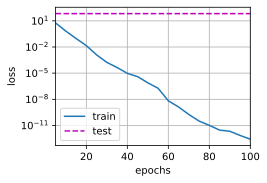

In [8]:
train(0)

holyshit

w的L2范数是： 0.032697323709726334


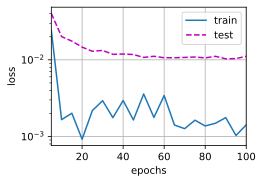

In [9]:
train(5)

holy shit


下面进行简洁实现

In [ ]:
def train_concise(wd):
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss(reduction='none')
    num_epochs, lr = 100, 0.003
    # 偏置参数没有衰减
    trainer = torch.optim.SGD([
        {"params":net[0].weight,'weight_decay': wd}, #等于在这一步就实现了权重衰退？   是的，直接把正则化后的倒数加到drop里面了
        {"params":net[0].bias}], lr=lr)              #这个net[0]指的是操作对象为第一层
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.mean().backward()
            trainer.step()
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1,
                         (d2l.evaluate_loss(net, train_iter, loss),
                          d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数：', net[0].weight.norm().item())
 

help(torch.optim.SGD)

Help on class SGD in module torch.optim.sgd:

class SGD(torch.optim.optimizer.Optimizer)
 |  SGD(params, lr: Union[float, torch.Tensor] = 0.001, momentum: float = 0, dampening: float = 0, weight_decay: float = 0, nesterov=False, *, maximize: bool = False, foreach: Optional[bool] = None, differentiable: bool = False, fused: Optional[bool] = None)
 |  
 |  Implements stochastic gradient descent (optionally with momentum).
 |  
 |  .. math::
 |     \begin{aligned}
 |          &\rule{110mm}{0.4pt}                                                                 \\
 |          &\textbf{input}      : \gamma \text{ (lr)}, \: \theta_0 \text{ (params)}, \: f(\theta)
 |              \text{ (objective)}, \: \lambda \text{ (weight decay)},                          \\
 |          &\hspace{13mm} \:\mu \text{ (momentum)}, \:\tau \text{ (dampening)},
 |          \:\textit{ nesterov,}\:\textit{ maximize}                                     \\[-1.ex]
 |          &\rule{110mm}{0.4pt}                      

w的L2范数： 13.77111530303955


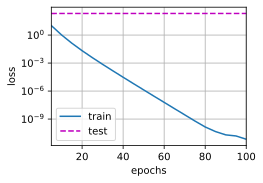

In [11]:
train_concise(0)

w的L2范数： 0.07728435844182968


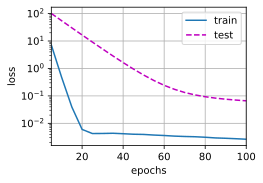

In [12]:
train_concise(5)

看一看训练后和lambda的关系

In [ ]:
import numpy as np

def lambd_loss(wd):
    net = nn.Sequential(nn.Linear(num_inputs,1))
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss(reduction='none')
    epochs, lr = 100, 0.003
    
    trainer = torch.optim.SGD([
        {"params":net[0].weight,'weight_decay':wd},
        {"params":net[0].bias}],lr=lr)
    for epoch in range(epochs):
        for x, y in train_iter:
            trainer.zero_grad()
            l = loss(net(x),y)
            l.mean().backward()
            trainer.step()
    
    return d2l.evaluate_loss(net, train_iter, loss), d2l.evaluate_loss(net, test_iter, loss)


def draw_lambd(max_lambd):
    animator = d2l.Animator(xlabel='lambd', ylabel='loss', yscale='linear',
                            xlim=[0, max_lambd], legend=['train', 'test'])
    for wd in range(0, max_lambd):
        animator.add(wd, lambd_loss(wd))
         
         

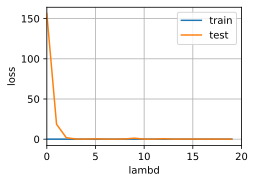

In [43]:
draw_lambd(20)

下面这一段代码要快了很多倍，原因应该是画的部分。上面的代码是动画，一遍一遍画，下面是全部搞完直接出图，算量差距很大。

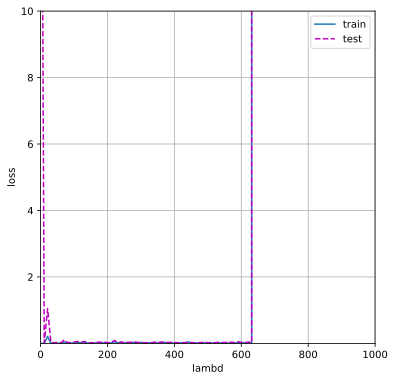

In [42]:
import numpy as np
lambds = np.arange(1,1000,10)
lambds = np.hstack(([0, 0.01, 0.1, 0.5],lambds))

def lambd_loss(wd):
    loss_ = []
    net = nn.Sequential(nn.Linear(num_inputs,1))
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss(reduction='none')
    epochs, lr = 100, 0.003
    
    trainer = torch.optim.SGD([
        {"params":net[0].weight,'weight_decay':wd},
        {"params":net[0].bias}],lr=lr)
    for epoch in range(epochs):
        for x, y in train_iter:
            trainer.zero_grad()
            l = loss(net(x),y)
            l.mean().backward()
            trainer.step()
    loss_.append([d2l.evaluate_loss(net, train_iter, loss), 
                     d2l.evaluate_loss(net, test_iter, loss)])
    return loss_

loss_s = []

for lambd in lambds:
    loss_s.append(lambd_loss(lambd))

loss_s = np.array(loss_s)

d2l.plot(lambds, [loss_s[:,:,0],loss_s[:,:,1]],'lambd','loss',
         legend=['train','test'],xlim=[0,1000],ylim=[1e-4,10],figsize=(6,6))